---------

Comments
- 9% of location data are missing, but:
    - For active users we do not need location data
    - The missing data will average out (likely the 9% is MCAR)

--------
# Barter Deals dataset


- Construct the main predictor $apps\_after\_7\_days$
- Construct MAU/WAU (monthly and weekly active users, based on how many creators applied to a deal)
- Use location data to get estimates on the nr. of 'eligible' creators: the number of creators that are withina certain range of a (physical) deal

In [224]:
import numpy as np
import pandas as pd
from src import paths
from collections import defaultdict


In [225]:
df_apps = pd.read_parquet(paths.RAW_DATA_DIR / 'BARTER_DEAL_APPLICATIONS.parquet')
df_deals = pd.read_parquet(paths.PROCESSED_DATA_DIR / 'BARTER_DEALS_CLEAN.parquet')

country_to_iso3 = {
    'Netherlands': 'NLD',
    'Germany': 'DEU',
    'Denmark': 'DNK',
    'Portugal': 'PRT',
    'Spain': 'ESP',
    'Sweden': 'SWE',
    'Belgium': 'BEL',
    'France': 'FRA',
    'Italy': 'ITA',
    'United Kingdom': 'GBR',
    'United States': 'USA', # Not in deals yet, but good for completeness
    'Poland': 'POL',
    'Greece': 'GRC',
    'Malta': 'MLT',
    'Ukraine': 'UKR'
}

# Recode creator countries to ISO3 in the unique creators dataframe
df_apps['country_code_creators'] = df_apps['country_creators'].map(country_to_iso3)


df_deals = pd.merge(df_deals, df_apps[['deal_id', 'company_location_id']].drop_duplicates(subset=['deal_id']), on='deal_id', how='left')

# Omit old data, missing location data for many creators, will not be used in regression and we retain sufficient observations
df_apps = df_apps[df_apps.application_created_at > "2025-01"]
df_deals = df_deals[df_deals.created_at > "2025-01"]


import ast
def tolist(row):
    try:
        return ast.literal_eval(row)
    except Exception as e:
        print(e)

df_apps['accepted_countries_deals'] = df_apps['accepted_countries_deals'].apply(tolist)

# Generate metrics

## Nr of unique active creators 


In [226]:
def get_daily_uniques(target_dates_ns, event_dates, creators, window_days):
    window_ns = pd.Timedelta(days=window_days).value
    n_events = len(event_dates)
    results = []
    
    counts = defaultdict(int)
    unique_count = 0
    
    left_ptr = 0
    right_ptr = 0
    
    # Iterate through each calendar day
    for current_day_ns in target_dates_ns:
        min_time_ns = current_day_ns - window_ns
        
        # EXPAND: Add events that happened before the current day
        while right_ptr < n_events and event_dates[right_ptr] < current_day_ns:
            inf = creators[right_ptr]
            if counts[inf] == 0:
                unique_count += 1
            counts[inf] += 1
            right_ptr += 1
            
        # SHRINK: Remove events that happened on or before the min_time (falling out of window)
        while left_ptr < right_ptr and event_dates[left_ptr] <= min_time_ns:
            inf = creators[left_ptr]
            counts[inf] -= 1
            if counts[inf] == 0:
                unique_count -= 1
            left_ptr += 1
            
        # Record the snapshot for this specific day
        results.append(unique_count)
        
    return results


def get_independent_actives(df, columns_list):
    """
    Calculates rolling active unique creators for each column independently,
    stacking them into a single 'Category' and 'Value' format.
    """
    # 1. Sort the main dataframe once (CRITICAL)
    df = df.sort_values('application_created_at').reset_index(drop=True)
    
    # 2. Establish the universal daily date range
    dateranges = pd.date_range(
        start=df['application_created_at'].min().normalize(), 
        end=df['application_created_at'].max().normalize(), 
        freq='D'
    )
    target_dates_ns = dateranges.astype('int64').values
    
    all_segments = []
    
    # 3. Loop through each column independently
    for col in columns_list:
        # Find the unique values for this specific column
        unique_values = df[col].dropna().unique()
        
        for val in unique_values:
            # Filter the data for just this value
            df_subset = df[df[col] == val]
            
            # Extract arrays for speed
            event_dates = df_subset['application_created_at'].astype('int64').values
            influencers = df_subset['creator_id'].values
            
            # Calculate the rolling metrics
            active_30 = get_daily_uniques(target_dates_ns, event_dates, influencers, 30)
            active_7 = get_daily_uniques(target_dates_ns, event_dates, influencers, 7)
            
            # Build the Tidy DataFrame for this specific slice
            df_temp = pd.DataFrame({
                'date': dateranges,
                'category': col,       # e.g., 'gender_creator' or 'country'
                'value': val,          # e.g., 'male' or 'Germany'
                'active_last_month': active_30,
                'active_last_week': active_7
            })
            
            all_segments.append(df_temp)
            
    # 4. Combine everything into one master DataFrame
    return pd.concat(all_segments, ignore_index=True)


In [227]:
df_apps_sorted = df_apps.sort_values('application_created_at').reset_index(drop=True)

event_dates = df_apps_sorted['application_created_at'].astype('int64').values
dateranges = pd.date_range(
    start=df_apps_sorted['application_created_at'].min().normalize(), 
    end=df_apps_sorted['application_created_at'].max().normalize(), 
    freq='D'
)
target_dates_ns = dateranges.astype('int64').values


creators = df_apps['creator_id'].values
# Convert the target daily dates to nanoseconds
df_active_creators = pd.DataFrame({'date': dateranges})
df_active_creators['active_last_month'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=30
)
df_active_creators['active_last_week'] = get_daily_uniques(
    target_dates_ns, event_dates, creators, window_days=7
)

In [228]:
df_active_creators

,date,active_last_month,active_last_week
0,2025-01-01,0,0
1,2025-01-02,148,148
2,2025-01-03,246,246
3,2025-01-04,342,342
4,2025-01-05,396,396
...,...,...,...
409,2026-02-14,947,1
410,2026-02-15,900,1
411,2026-02-16,867,1
412,2026-02-17,832,1


## Apps after 7 days

In [229]:
# # Known to be correct (ground truth), but inefficient; prefer vectorized function (faster)

# def apps_after_n_days(row, n=7):
#     subs = df_apps[df_apps['deal_id'] == row['deal_id']]
#     if len(subs) != row['applicants_applications_count']:
#         subs = subs[subs['deleted_at'].isna()]

#     # "created_at" is the date on which the application log entry was created (application was made)
#     days_since_live = (subs.application_created_at - row.live_since).dt.days
#     return ((days_since_live >= 0) & (days_since_live <= n)).sum()

# apps_after_7_days = df_deals.apply(apps_after_n_days, axis=1)
# df_deals['apps_after_7_days'] = apps_after_7_days


def calculate_target_vectorized(df_deals, df_apps, n=7):
    # 1. Pre-calculate the total rows in df_apps per deal to replicate your exact 'quirk' logic
    app_counts = df_apps.groupby('deal_id').size().reset_index(name='actual_app_count')
    
    # 2. Merge only the necessary columns to save memory
    merged = df_apps[['deal_id', 'application_created_at', 'deleted_at']].merge(
        df_deals[['deal_id', 'live_since', 'applicants_applications_count']], 
        on='deal_id', 
        how='inner'
    )
    
    # Add our actual counts back into the merged dataframe
    merged = merged.merge(app_counts, on='deal_id', how='left')

    # 3. Calculate the days since live in one vectorized sweep
    # (Ensure both columns are datetime objects before this step)
    merged['days_since_live'] = (merged['application_created_at'] - merged['live_since']).dt.days

    # 4. Apply the time window mask
    time_mask = (merged['days_since_live'] >= 0) & (merged['days_since_live'] <= n)
    
    # 5. Apply your specific data-quirk mask (deleted_at logic)
    quirk_mask = (merged['actual_app_count'] == merged['applicants_applications_count']) | \
                 (merged['deleted_at'].isna())
                 
    # Combine masks and filter
    valid_apps = merged[time_mask & quirk_mask]

    # 6. Group by deal_id to get the final count
    target_counts = valid_apps.groupby('deal_id').size().reset_index(name=f'apps_after_{n}_days')

    # 7. Merge back to the original deals dataframe (Left merge to keep deals with 0 apps)
    df_deals_updated = df_deals.merge(target_counts, on='deal_id', how='left')
    
    # Fill NaN values with 0 (deals that received no valid applications in the window)
    df_deals_updated[f'apps_after_{n}_days'] = df_deals_updated[f'apps_after_{n}_days'].fillna(0).astype(int)
    
    return df_deals_updated

# Execution:
# Ensure datetimes are set first:
# df_deals['live_since'] = pd.to_datetime(df_deals['live_since'])
# df_apps['application_created_at'] = pd.to_datetime(df_apps['application_created_at'])

df_deals = calculate_target_vectorized(df_deals, df_apps, n=7)


# Eligible users: Location/Geography

## Online deals

In [230]:
active_by_country = get_independent_actives(df_apps, ['country_code_creators']).sort_values('date')
active_by_country

,date,category,value,active_last_month,active_last_week
0,2025-01-01,country_code_creators,NLD,0,0
828,2025-01-01,country_code_creators,BEL,0,0
4554,2025-01-01,country_code_creators,UKR,0,0
414,2025-01-01,country_code_creators,SWE,0,0
1242,2025-01-01,country_code_creators,DEU,0,0
...,...,...,...,...,...
1241,2026-02-18,country_code_creators,BEL,132,0
827,2026-02-18,country_code_creators,SWE,0,0
413,2026-02-18,country_code_creators,NLD,532,2
4553,2026-02-18,country_code_creators,DNK,0,0


In [231]:
active_by_country.columns

Index(['date', 'category', 'value', 'active_last_month', 'active_last_week'], dtype='object')

In [232]:
df_active_wide = active_by_country.pivot(index='date', columns=['value'], values=['active_last_month', 'active_last_week'])
df_active_wide.columns = [f"{metric}_{country}" for metric, country in df_active_wide.columns]
df_active_wide = df_active_wide.reset_index()
df_active_wide


,date,active_last_month_BEL,active_last_month_DEU,active_last_month_DNK,active_last_month_ESP,active_last_month_FRA,active_last_month_GBR,active_last_month_ITA,active_last_month_NLD,active_last_month_PRT,...,active_last_week_DNK,active_last_week_ESP,active_last_week_FRA,active_last_week_GBR,active_last_week_ITA,active_last_week_NLD,active_last_week_PRT,active_last_week_SWE,active_last_week_UKR,active_last_week_USA
0,2025-01-01,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2025-01-02,4,0,0,0,0,0,0,44,0,...,0,0,0,0,0,44,0,1,0,0
2,2025-01-03,8,1,0,0,0,0,0,83,0,...,0,0,0,0,0,83,0,1,0,0
3,2025-01-04,14,1,0,1,0,1,0,118,0,...,0,1,0,1,0,118,0,1,0,0
4,2025-01-05,16,1,0,1,0,1,0,139,0,...,0,1,0,1,0,139,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,2026-02-14,166,91,0,4,0,13,0,631,0,...,0,0,0,0,0,1,0,0,0,0
410,2026-02-15,145,83,0,3,0,13,0,596,0,...,0,0,0,0,0,1,0,0,0,0
411,2026-02-16,143,82,0,2,0,12,0,565,0,...,0,0,0,0,0,1,0,0,0,0
412,2026-02-17,137,80,0,2,0,11,0,549,0,...,0,0,0,0,0,1,0,0,0,0


In [233]:
df_deals_wactives = pd.merge_asof(df_deals.sort_values('created_at'),
              df_active_wide.sort_values('date'),
              left_on='created_at',
              right_on='date')

In [234]:
country_creators_list = df_apps.country_code_creators.unique()

def return_actives(row):
    accepted_countries = [x for x in row['accepted_countries'] if x in country_creators_list] 
    
    month_cols = [f"active_last_week_{x}" for x in accepted_countries]
    week_cols = [f"active_last_month_{x}" for x in accepted_countries]

    # return [row[month_cols].sum(), row[week_cols].sum()]

    return pd.Series(
        {"eligible_last_week": row[week_cols].sum(),
         "eligible_last_month": row[month_cols].sum()}
         )

df_deals_wactives.apply(return_actives, axis=1)
df_deals_wactives[['online_eligible_last_week', 'online_eligible_last_month']] = df_deals_wactives.apply(return_actives, axis=1)
df_deals_wactives.loc[df_deals_wactives['deal_type'] == 'physical', ['online_eligible_last_week', 'online_eligible_last_month']] = 0

df_deals = df_deals_wactives.drop(columns=df_active_wide.columns)


## Physical deals (active users within $n$ km)

In [235]:
import numpy as np

def calculate_haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Calculates the great-circle distance between two points 
    on the Earth surface in kilometers using NumPy arrays.
    """
    # Earth radius in kilometers
    R = 6371.0 
    
    # Convert degrees to radians (NumPy trig functions require radians)
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)
    
    # Calculate differences
    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad
    
    # Apply the Haversine formula
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2.0)**2
    
    # arcsin is mathematically equivalent to arctan2 for this and often slightly faster in numpy
    c = 2 * np.arcsin(np.sqrt(a)) 
    
    # Return distance in kilometers
    return R * c

1. Create spatial grid: distance between unique company locations and creator locations
2. Filter the creators that are within an eligible range (e.g., 25km)
    - Maybe explore whether I can come up with a metric that is a function of distance, e.g. weighted by distance from deal location
3. Per deal:
    - Total active (eligible) creators in last 7 days/30 days
        - Consider Pro creators? (creators with high follower count/ good reviews)


1. The Pre-Computed Spatial Grid (Calculate Once)

Do not calculate distances between deals and creators. Calculate distances between Unique Deal Locations and Unique Creator Locations.

Locations don't move. A coordinate in Amsterdam is always the same distance from a coordinate in Utrecht.

In [236]:
# Filter for physical deals with valid locations
df_locs = df_apps[~df_apps['company_location_id'].isna() & (df_apps['deal_type_deals'] == 'physical')]

# 2. Unique Deals/Company Locations 
# Grouped by deal_id (to easily merge back to df_deals later)
df_unique_deals = df_locs[['deal_id', 'latitude_company_locations', 'longitude_company_locations', 'country_code_creators']].drop_duplicates(subset=['deal_id'])

# 1. Unique Company Locations (1014 rows)
df_unique_locations = df_locs[[
    'company_location_id', 
    'latitude_company_locations', 
    'longitude_company_locations'
]].drop_duplicates(subset=['company_location_id'])

# 2. Unique Creators (6696 rows)
df_unique_creators = df_locs[[
    'creator_id', 
    'latitude_creators', 
    'longitude_creators',
    'country_code_creators'
]].drop_duplicates(subset=['creator_id'])


# Handle the <NA> or unmapped values: we can't assume eligibility if we don't know the country
## Large amount of missingness, but only before approx. 2025, so we can ignore it (make sure to drop data before 2025 for regression)
df_unique_creators = df_unique_creators.dropna(subset=['country_code_creators'])

# 3. The Leaner Cross-Join (~6.79 million rows)
df_spatial_grid = df_unique_locations.merge(df_unique_creators, how='cross')

# 4. Calculate Distances Vectorially
df_spatial_grid['distance_km'] = calculate_haversine_vectorized(
    df_spatial_grid['latitude_company_locations'].values,
    df_spatial_grid['longitude_company_locations'].values,
    df_spatial_grid['latitude_creators'].values,
    df_spatial_grid['longitude_creators'].values
)



In [237]:

# 5. Immediately Filter by Radius (e.g., 50km) and drop coordinates
radius_km = 50.0
df_spatial_grid = df_spatial_grid[df_spatial_grid['distance_km'] <= radius_km]
# df_spatial_grid = df_spatial_grid[['company_location_id', 'creator_id', 'distance_km', 'creator_country_code']]

# 6. Map the Spatial Matches Back to the Deals
# We merge the pruned spatial grid with your deals metadata to re-attach the deal_id 
# and the highly crucial created_at timestamp needed for the next step.
df_deals_spatial = df_deals[['deal_id', 'company_location_id', 'created_at', 'accepted_countries']].merge(
    df_spatial_grid, 
    on='company_location_id', 
    how='inner' # Inner join ensures we only keep deals that have creators within the radius
)

In [238]:
# 3. Optimized Eligibility Filter
# Use a list comprehension for high-speed membership checking
df_deals_spatial['is_eligible'] = [
    code in accepted_list if isinstance(accepted_list, list) else True
    for code, accepted_list in zip(df_deals_spatial['country_code_creators'], df_deals_spatial['accepted_countries'])
]

# 4. Final Pruning
df_deals_spatial = df_deals_spatial[df_deals_spatial['is_eligible']]
df_deals_spatial = df_deals_spatial.drop(columns=['is_eligible', 'country_code_creators', 'accepted_countries'])

In [239]:
df_model = df_deals.copy()
# 1. Prepare a clean activity log (just IDs and timestamps)
df_activity = df_apps[['creator_id', 'application_created_at']].drop_duplicates()

# 2. Merge spatial matches with the activity log
# This creates a "Possibility" table
df_liquidity = df_deals_spatial.merge(df_activity, on='creator_id', how='inner')

# 3. Calculate the time window (Vectorized)
# Ensure both are datetime objects
df_liquidity['days_diff'] = (df_liquidity['created_at'] - df_liquidity['application_created_at']).dt.days

# 4. Filter for activity in the last 30 days PRIOR to the deal creation
# (diff >= 0 means activity happened before or on the day of the deal)

for daysdiff in [7, 30]:
    mask = (df_liquidity['days_diff'] >= 0) & (df_liquidity['days_diff'] <= 7)
    df_active_liquidity = df_liquidity[mask]

    # 5. Final Aggregation: Count unique creators per deal
    liquidity_feature = df_active_liquidity.groupby('deal_id')['creator_id'].nunique().reset_index(name=f'physical_active_creators_{daysdiff}d_50km')

    # 6. Map back to your main model dataframe
    df_model = df_model.merge(liquidity_feature, on='deal_id', how='left')
    df_model[f'physical_active_creators_{daysdiff}d_50km'] = df_model[f'physical_active_creators_{daysdiff}d_50km'].fillna(0).astype(int)

In [240]:
# 1. Sort your model dataframe by the deal creation time
df_model = df_model.sort_values('created_at')
# Ensure the daily dataframe is sorted by date
df_active_creators = df_active_creators.sort_values('date')

# 2. Use merge_asof to align the daily marketplace metrics to the deal timestamp
df_model = pd.merge_asof(
    df_model, 
    df_active_creators, 
    left_on='created_at', 
    right_on='date', 
    direction='backward' # Looks for the most recent preceding daily record
)

# 3. Clean up the extra 'date' column from the merge
df_model = df_model.drop(columns=['date'])

## Include online eligibility (does creator live in accepted_countries?)

In [241]:
def engineer_dgp_liquidity(df, df_country_liquidity):
    """
    df: Your main deals dataframe (already contains active_creators_30d_50km)
    df_country_liquidity: A dataframe with ['date', 'country_code', 'active_30d']
    """
    df = df.copy()
    
    # 1. Initialize both columns to 0
    df['liquidity_physical_30d'] = 0.0
    df['liquidity_online_30d'] = 0.0
    
    # 2. Assign Physical Liquidity
    # Only physical deals get the 50km radius liquidity
    physical_mask = df['deal_type'] == 'physical'
    df.loc[physical_mask, 'liquidity_physical_30d'] = df.loc[physical_mask, 'active_creators_30d_50km']
    
    # 3. Assign Online Liquidity
    # We need to sum the 30-day active users for the accepted countries at the time of created_at
    
    def get_online_liquidity(row):
        if row['deal_type'] != 'online':
            return 0.0
            
        deal_date = row['created_at'].normalize()
        countries = row['accepted_countries'] # e.g., ['NLD', 'BEL']
        
        if not isinstance(countries, list) or len(countries) == 0:
            return 0.0
            
        # Filter the country liquidity table for the specific date and accepted countries
        # (In a highly optimized pipeline, you'd do this via an exact merge_asof, 
        # but this row-wise logic is safe and clear for the complex list-lookup)
        mask = (
            (df_country_liquidity['date'] == deal_date) & 
            (df_country_liquidity['country_code'].isin(countries))
        )
        return df_country_liquidity.loc[mask, 'active_30d'].sum()

    df['liquidity_online_30d'] = df.apply(get_online_liquidity, axis=1)
    
    # 4. Apply Log Transformations (using log1p to handle the structural zeros safely)
    df['log_liquidity_physical_30d'] = np.log1p(df['liquidity_physical_30d'])
    df['log_liquidity_online_30d'] = np.log1p(df['liquidity_online_30d'])
    
    return df

In [242]:
df_apps.drop_duplicates(['country_code_creators', 'country_creators'])[['country_code_creators', 'country_creators']]

,country_code_creators,country_creators
36,NLD,Netherlands
46,DEU,Germany
147,BEL,Belgium
1824,ESP,Spain
3128,GBR,United Kingdom
6412,SWE,Sweden
6634,NaN,<NA>
13534,FRA,France
20131,PRT,Portugal
22507,USA,United States


In [243]:
df_apps.country_code_creators.value_counts()

country_code_creators
NLD    131793
BEL     26799
DEU      8175
GBR      5040
ESP      3511
SWE       454
FRA       328
USA       189
ITA        67
PRT        65
DNK        13
UKR         1
Name: count, dtype: int64

# Check & save

In [245]:
df_model

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,title_word_count,days_since_start,company_location_id,apps_after_7_days,online_eligible_last_week,online_eligible_last_month,physical_active_creators_7d_50km,physical_active_creators_30d_50km,active_last_month,active_last_week
0,0,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e4-4d11-00c8-e3cc-63339a3cec9a,uploads/deals/019689e4-4e14-ffff-9848-e15f0f2f...,5000,None,2025-01-01 10:31:48.668013,NaT,NaT,None,...,2,482,<NA>,0,0,0,0,0,0,0
1,0,"[{'id': 30, 'name': 'Finance', 'slug': 'Coin'}...",019689e4-4ed5-00c8-2e3c-eabfa471458a,uploads/deals/019689e4-4fb1-ffff-2e57-f8fef1d8...,5000,None,2025-01-01 10:35:31.071813,NaT,NaT,None,...,2,482,<NA>,0,0,0,0,0,0,0
2,0,"[{'id': 19, 'name': 'Sport', 'slug': 'Soccer-B...",019689e4-506b-00c8-a61a-5cc41e1d5278,uploads/deals/019689e4-519a-ffff-468a-a893c987...,5000,None,2025-01-01 10:52:34.332511,NaT,NaT,"[{""id"": ""01KERHXE5B05FSE2CE9BYTNFB6"", ""name"": ...",...,2,482,<NA>,0,0,0,0,0,0,0
3,6,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019689e4-528b-00c8-bce1-1b8f34b1c0b9,uploads/deals/019689e4-5395-ffff-7f3f-070e9556...,10000,None,2025-01-02 13:05:52.205770,2025-01-07 09:08:34.219652,2025-01-18 21:25:52.990225,"[{""id"": ""01KERHV8RY05FQK4NHKXG2R5HS"", ""name"": ...",...,3,483,019bb11d-a31e-015f-7992-b19f602c1639,3,0,0,32,32,148,148
4,0,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019689e4-5484-00c8-d726-07b3c443edd8,uploads/deals/019689e4-558a-ffff-9da6-c1c74a05...,5000,None,2025-01-02 14:39:48.856076,NaT,NaT,"[{""id"": ""01KERHT1N605FSW0NPCQ1E7J3A"", ""name"": ...",...,6,483,019bb11d-06a6-015f-9e02-b665c2e3c86a,0,0,0,29,29,148,148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4659,2,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019c0b54-a139-00c8-6c0f-67d89c75632c,uploads/deals/019c0b58-380f-ffff-4d40-98dd9764...,1500,None,2026-01-29 20:01:14.400677,2026-01-29 21:05:15.863441,2026-01-30 06:19:24.501434,None,...,5,875,<NA>,2,1148,541,0,0,1263,622
4660,25,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019c0b5a-464e-00c8-762c-376fc87682da,uploads/deals/019c0b5b-a1a5-ffff-481e-2544725d...,5000,None,2026-01-29 20:05:04.885661,2026-01-29 20:12:56.888284,2026-01-30 06:55:05.359563,None,...,6,875,<NA>,25,1148,541,0,0,1263,622
4661,1,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}]",019c0bd3-6842-00c8-a7b2-dfa4df49d243,uploads/deals/019c0bce-ee0a-ffff-1c58-3cef5947...,5000,None,2026-01-29 22:15:30.192439,2026-01-29 22:56:35.286760,2026-01-29 22:56:35.286760,None,...,3,875,<NA>,1,1029,487,0,0,1263,622
4662,3,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019c2920-e1cf-00c8-86b7-30ddb43064d3,uploads/deals/019c2920-ab62-ffff-5a76-c5271c5a...,1500,None,2026-02-04 14:49:45.672146,2026-02-04 14:58:55.555753,2026-02-04 14:58:55.555753,None,...,6,881,<NA>,1,779,232,0,0,1212,274


In [246]:
df_model.to_parquet(paths.PROCESSED_DATA_DIR/'BARTER_DEALS_MODEL_DF.parquet')

# EDA

In [ ]:
df_apps[(~df_apps.company_location_id.isna()) & (df_apps.deal_type_deals=='online')]

,legacy_location_id,deal_id,creator_id,rescheduling_deal_application_id,schedule_date,application_status,cancelled_at,cancelled_by,cancelled_by_user_id,cancellation_reason,...,email_address_partners,registered_at_partners,subscription_status_partners,subscription_start_date_partners,subscription_end_date_partners,deals_count_partners,live_deals_count_partners,locations_count_partners,company_size_partners,worked_with_creators_partners
65,944,019689e2-2164-00c8-219f-7087bbc8918a,3534,<NA>,2025-01-10 00:00:00+00:00,cancelled,NaT,<NA>,NaN,<NA>,...,williamson@anonymized.getbarter.com,2024-10-08 13:17:07.479173+00:00,cancelled,2024-10-15 19:21:16+00:00,2025-01-15 19:21:16+00:00,3.0,0.0,2.0,<NA>,<NA>
173,334,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,2972,<NA>,2024-02-29 00:00:00+00:00,cancelled,NaT,<NA>,NaN,<NA>,...,rempel.kelli@anonymized.getbarter.com,2024-02-15 08:37:12.847565+00:00,active,2025-09-08 16:41:52+00:00,2026-02-08 17:41:52+00:00,3.0,0.0,1.0,<NA>,<NA>
174,334,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,8023,<NA>,2024-03-29 00:00:00+00:00,cancelled,NaT,<NA>,NaN,<NA>,...,rempel.kelli@anonymized.getbarter.com,2024-02-15 08:37:12.847565+00:00,active,2025-09-08 16:41:52+00:00,2026-02-08 17:41:52+00:00,3.0,0.0,1.0,<NA>,<NA>
175,334,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,1552,<NA>,2024-02-21 00:00:00+00:00,cancelled,NaT,<NA>,NaN,<NA>,...,rempel.kelli@anonymized.getbarter.com,2024-02-15 08:37:12.847565+00:00,active,2025-09-08 16:41:52+00:00,2026-02-08 17:41:52+00:00,3.0,0.0,1.0,<NA>,<NA>
176,334,019689e3-9cb7-00c8-89ef-3f2888a9c4bd,1299,<NA>,2024-03-02 00:00:00+00:00,rejected,NaT,<NA>,NaN,<NA>,...,rempel.kelli@anonymized.getbarter.com,2024-02-15 08:37:12.847565+00:00,active,2025-09-08 16:41:52+00:00,2026-02-08 17:41:52+00:00,3.0,0.0,1.0,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269638,2047,019689e2-e5f8-00c8-bdd3-479d5421aa82,16575,<NA>,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:09:33.367384+00:00,creator,25389.0,,...,lowe.mason@anonymized.getbarter.com,2025-04-07 15:11:32.532398+00:00,active,2025-04-17 10:43:16+00:00,2026-04-17 10:43:16+00:00,5.0,5.0,3.0,<NA>,<NA>
269685,1942,019689e3-c220-00c8-e721-46b334a9cac1,16575,<NA>,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:11:31.962628+00:00,creator,25389.0,,...,felicia.terry@anonymized.getbarter.com,2025-03-19 14:03:05.368404+00:00,active,2025-03-19 14:02:58+00:00,2026-04-23 22:00:00+00:00,6.0,0.0,2.0,<NA>,<NA>
269690,1448,019689e2-2f95-00c8-c61c-efcc1098e57b,16575,<NA>,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:11:39.588509+00:00,creator,25389.0,,...,felipa.durgan@anonymized.getbarter.com,2025-01-16 15:03:52.995457+00:00,cancelled,2025-06-16 12:04:18+00:00,2025-09-18 14:03:11+00:00,2.0,0.0,1.0,<NA>,<NA>
269724,2072,019689e3-8231-00c8-45a1-02e2709942dc,16575,<NA>,2025-04-29 00:00:00+00:00,cancelled,2025-12-09 14:08:35.808610+00:00,creator,25389.0,,...,dell.tillman@anonymized.getbarter.com,2025-04-10 10:42:00.447860+00:00,cancelled,2025-04-17 10:23:51+00:00,2025-07-17 10:23:51+00:00,4.0,0.0,1.0,<NA>,<NA>


## Analysing missingness in creator_location_id

We observe that 23% of creator locations are missing for physical deals. Is it MCAR?

- We online consider data starting from 2025-04, since we detected a structural change, retaining 50% of data. This way we are modelling a stable DGP. The missingness drops to 0% 2 months before that time, which is necessary, since the liquidity with missingness is artifically deflated. 

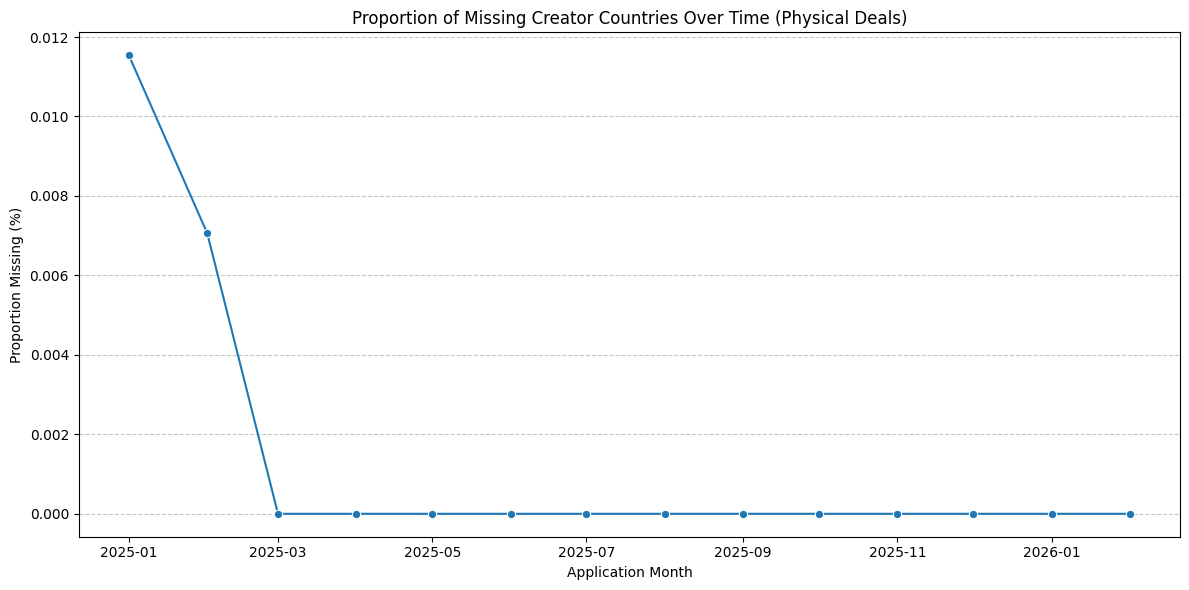

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Isolate the relevant subset of physical applications
df_phys_apps = df_apps[
    (~df_apps['company_location_id'].isna()) & 
    (df_apps['deal_type_deals'] == 'physical')
].copy()

# 2. Create a boolean flag for missing creator country
df_phys_apps['missing_country'] = df_phys_apps['country_creators'].isna()

# 3. Truncate application dates to the Month (or Week) for smooth plotting
df_phys_apps['app_month'] = df_phys_apps['application_created_at'].dt.to_period('M').dt.to_timestamp()

# 4. Calculate the proportion of missing data per month
missing_over_time = df_phys_apps.groupby('app_month')['missing_country'].mean().reset_index()

# 5. Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=missing_over_time, x='app_month', y='missing_country', marker='o')
plt.title('Proportion of Missing Creator Countries Over Time (Physical Deals)')
plt.ylabel('Proportion Missing (%)')
plt.xlabel('Application Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
missing_over_time

,app_month,missing_country
0,2023-09-01,0.117021
1,2023-10-01,0.399531
2,2023-11-01,0.382391
3,2023-12-01,0.493306
4,2024-01-01,0.285788
5,2024-02-01,0.330209
6,2024-03-01,0.222894
7,2024-04-01,0.210290
8,2024-05-01,0.127263
9,2024-06-01,0.133652


In [ ]:
missingness_analysis

,deal_id,apps_after_7_days,total_apps,missing_country_count,pct_missing_country
0,019689e2-23f5-00c8-7750-d15e1f1a744c,0,11,4,0.363636
1,019689e2-3894-00c8-fe6d-4a77d3c06a12,0,32,9,0.281250
2,019689e2-4765-00c8-e0ce-3e3fd5420cb9,0,29,12,0.413793
3,019689e2-4956-00c8-fd90-4ae0df34b4dd,0,198,54,0.272727
4,019689e2-500d-00c8-7e6b-5522ac71568e,0,5,1,0.200000
...,...,...,...,...,...
1745,019b9d25-68f7-00c8-81a5-457b86b616dd,5,5,0,0.000000
1746,019ba21a-add8-00c8-b49d-afa35f19f3ea,11,13,0,0.000000
1747,019ba40d-36b8-00c8-4c54-10d1badad438,17,31,0,0.000000
1748,019bd630-b2ca-00c8-cc1f-1655d674b138,0,2,0,0.000000


Correlation between Log(Y) and % Missing Creator Country: -0.0672


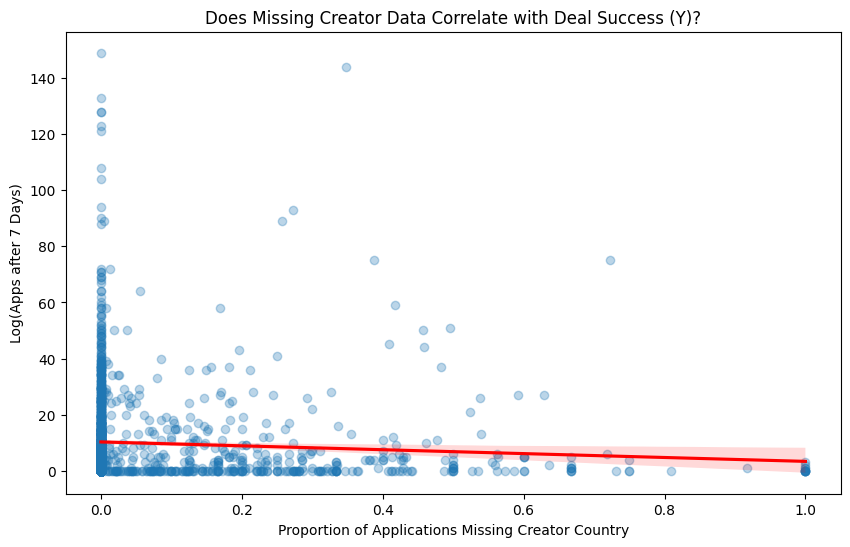

In [ ]:
# 1. Calculate the missingness rate per deal in the application log
deal_missing_rates = df_phys_apps.groupby('deal_id').agg(
    total_apps=('creator_id', 'size'),
    missing_country_count=('missing_country', 'sum')
).reset_index()

# Calculate the percentage of apps that have a missing creator country
deal_missing_rates['pct_missing_country'] = deal_missing_rates['missing_country_count'] / deal_missing_rates['total_apps']

# 2. Merge this missingness metric with your main model dataframe containing Y
missingness_analysis = df_model[['deal_id', 'apps_after_7_days']].merge(
    deal_missing_rates, 
    on='deal_id', 
    how='inner'
)

# 3. Check the correlation between Y (log_apps) and the rate of missingness
correlation = missingness_analysis['apps_after_7_days'].corr(missingness_analysis['pct_missing_country'])
print(f"Correlation between Log(Y) and % Missing Creator Country: {correlation:.4f}")

# 4. Visual Inspection: Scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=missingness_analysis, 
    x='pct_missing_country', 
    y='apps_after_7_days',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)
plt.title('Does Missing Creator Data Correlate with Deal Success (Y)?')
plt.xlabel('Proportion of Applications Missing Creator Country')
plt.ylabel('Log(Apps after 7 Days)')
plt.show()